In [ ]:
#install necessary libraries
!pip install speechbrain torch torchvision torchaudio librosa matplotlib scipy

In [4]:
#Import necessary libraries
import os
import sys
import torch
import json
import matplotlib.pyplot as plt
import numpy as np
import librosa
import torch
import torchaudio
import ipywidgets as widgets
from IPython.display import display, clear_output
import soundfile as sf

#From other folders
sys.path.append(os.path.abspath("./hifi-gan"))
from env import AttrDict
from models import Generator

#Check if GPU (CUDA) is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Tacotron 2 - Pipe 1: Text to Mel-Spectrogram

In [5]:
# Tacotron2 Text to Mel-Spectrogram by SpeechBrain
# load pretrained Tacotron2 model
from speechbrain.pretrained import Tacotron2
text_to_mel = Tacotron2.from_hparams(source="speechbrain/tts-tacotron2-ljspeech", savedir="pretrained_models/tts-tacotron2-ljspeech")

In [6]:
#Funtion to convert text to mel spectrogram
def text_to_mel_spectrogram(input_text):
    print(f"Input Text: {input_text}")
    #generate only mel spectrogram from text
    mel_out, _, alignments = text_to_mel.encode_batch(
        [input_text]
    )
    mel_spectrogram = mel_out.transpose(1, 2)
    return mel_spectrogram, alignments

#Example usage
input_text = "Hello world! Welcome to text to speech synthesis."
mel_spectrogram, alignments = text_to_mel_spectrogram(input_text)
# Turn mel spectrogram shape from [1, Time, 80] to [1, 80, Time]
mel_spectrogram = mel_spectrogram.transpose(1, 2)
print(f"Mel Spectrogram Shape: {mel_spectrogram.shape}")

Input Text: Hello world! Welcome to text to speech synthesis.
Mel Spectrogram Shape: torch.Size([1, 80, 331])


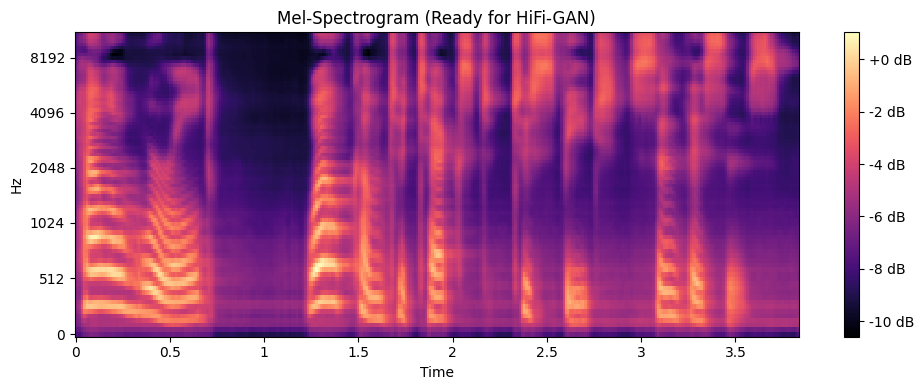

In [7]:
%matplotlib inline 

def show_mel(mel_tensor):
    mel_data = mel_tensor.squeeze().cpu().numpy()
    
    if mel_data.shape[0] != 80:
        mel_data = mel_data.T 
    
    plt.figure(figsize=(10, 4))
    
    librosa.display.specshow(
        mel_data, 
        sr=22050, 
        hop_length=256, 
        x_axis='time', 
        y_axis='mel', 
        cmap='magma'
    )
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel-Spectrogram (Ready for HiFi-GAN)')
    plt.tight_layout()
    plt.show()
show_mel(mel_spectrogram)

# HiFiGAN - Pipe 2: Mel-Spectrogram to Sound

In [8]:
#Function to load HiFi-GAN model from checkpoint (pretrained weights)
def load_hifigan_model(config_path, checkpoint_path, device):
    # Load model configuration
    with open(config_path) as f:
        config = json.load(f)
    h = AttrDict(config)
    
    # Initialize HiFi-GAN generator model
    model = Generator(h).to(device)
    
    # Load pretrained weights
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['generator'])
    model.eval()
    
    return model
# Load HiFi-GAN model
hifigan_config_path = "./hifi-gan/config.json"
hifigan_checkpoint_path = "./hifi-gan/generator_v3.pt"
hifigan_model = load_hifigan_model(hifigan_config_path, hifigan_checkpoint_path, device)

/home/zhu/micromamba/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Generated Waveform Shape: torch.Size([1, 1, 84736])


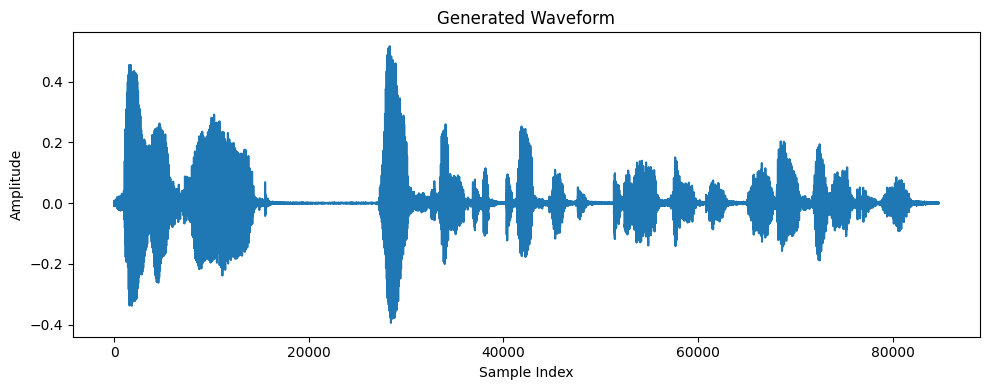

In [9]:
#Convert mel spectrogram to waveform using HiFi-GAN
def mel_to_waveform(mel_spectrogram, hifigan_model, device):
    # Ensure mel spectrogram is on the correct device
    mel_spectrogram = mel_spectrogram.to(device)
    
    # Generate waveform with HiFi-GAN
    with torch.no_grad():
        waveform = hifigan_model(mel_spectrogram)
    
    return waveform.cpu()
# Generate waveform from mel spectrogram
waveform = mel_to_waveform(mel_spectrogram, hifigan_model, device)
print(f"Generated Waveform Shape: {waveform.shape}")

# Waveform visualization
plt.figure(figsize=(10, 4))
plt.plot(waveform.squeeze().numpy())
plt.title("Generated Waveform")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [10]:
# Save the generated waveform as WAV
sf.write('generated_speech.wav', waveform.squeeze(), 22050)
print("Saved generated speech to 'generated_speech.wav'")

# Play audio in notebook
from IPython.display import Audio
Audio(waveform.squeeze(), rate=22050)

Saved generated speech to 'generated_speech.wav'


# Demo app

In [ ]:
# make an app to input text and output speech use ipywidgets
# Text input widget
text_input = widgets.Text(
    placeholder='Type something',
    description='Input Text:',
    disabled=False
)
# Button to generate speech
generate_button = widgets.Button(
    description='Generate Speech',
    disabled=False,
    button_style='success',
    tooltip='Click to generate speech from text',
    icon='microphone'
)
# Output area to display results
output_area = widgets.Output()
# Function to handle button click
def on_generate_button_clicked(b):
    with output_area:
        clear_output()
        input_text = text_input.value
        print(f"Generating speech for: {input_text}")
        mel_spectrogram, _ = text_to_mel_spectrogram(input_text)
        mel_spectrogram = mel_spectrogram.transpose(1, 2)
        waveform = mel_to_waveform(mel_spectrogram, hifigan_model, device)
        print("Generated Waveform:")
        plt.figure(figsize=(10, 4))
        plt.plot(waveform.squeeze().numpy())
        plt.title("Generated Waveform")
        plt.xlabel("Sample Index")
        plt.ylabel("Amplitude")
        plt.tight_layout()
        plt.show()
        display(Audio(waveform.squeeze(), rate=22050))
# Attach the click event to the button
generate_button.on_click(on_generate_button_clicked)
# Display the widgets
display(text_input, generate_button, output_area)

Text(value='', description='Input Text:', placeholder='Type something')

Button(button_style='success', description='Generate Speech', icon='microphone', style=ButtonStyle(), tooltip=…

Output()